In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

# Set style for plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [53]:
# Load train and test splits saved earlier
train_df = pd.read_csv('../data/processed/train.csv')
test_df = pd.read_csv('../data/processed/test.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")

X_train = train_df['review']
y_train = train_df['label']
X_test = test_df['review']
y_test = test_df['label']

print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Train shape: (40000, 2)
Test shape: (10000, 2)
Training set size: 40000
Test set size: 10000


In [69]:
# Create a pipeline
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,        # already lowercased in preprocessing, but safe
        stop_words='english',   # remove stopwords (though we already did, but again for safety)
        max_features=5000,      # limit vocabulary size
        ngram_range=(1,2)       # include unigrams and bigrams
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


In [70]:
# Predictions
y_pred_train = pipeline.predict(X_train)
y_pred_test = pipeline.predict(X_test)

# Metrics
train_f1 = f1_score(y_train, y_pred_train)
test_f1 = f1_score(y_test, y_pred_test)
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("Baseline Model Performance:")
print(f"Train F1 Score: {train_f1:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred_test, target_names=['negative', 'positive']))

Baseline Model Performance:
Train F1 Score: 0.9053
Test F1 Score: 0.8857
Train Accuracy: 0.9043
Test Accuracy: 0.8845

Classification Report (Test Set):
              precision    recall  f1-score   support

    negative       0.89      0.87      0.88      5000
    positive       0.88      0.89      0.89      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



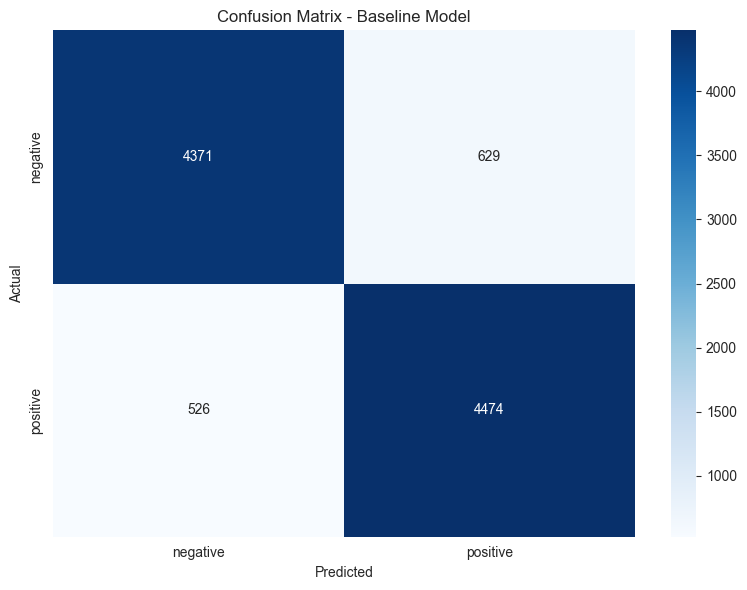

Cross-Validation F1 Scores: [0.88692666 0.8777709  0.88627354 0.87980356 0.87908295]
Mean CV F1: 0.8820 (+/- 0.0077)


In [71]:


# Confusion matrix - baseline
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Baseline Model')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix_baseline.png', dpi=300, bbox_inches='tight')
plt.show()

# Cross-validation on baseline
cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1')
print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")



In [72]:

# =============================================================================
# 4. Hyperparameter Tuning with GridSearchCV
# =============================================================================
param_grid = {
    'tfidf__max_features': [3000, 5000, 7000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

print("Starting grid search... This may take a few minutes.")
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1 score:", grid_search.best_score_)

Starting grid search... This may take a few minutes.
Fitting 3 folds for each of 18 candidates, totalling 54 fits
Best parameters: {'clf__C': 1, 'tfidf__max_features': 7000, 'tfidf__ngram_range': (1, 2)}
Best cross-validation F1 score: 0.8820423387212123



Best Model Performance:
Test F1 Score: 0.8881
Test Accuracy: 0.8868

Classification Report (Test Set - Best Model):
              precision    recall  f1-score   support

    negative       0.90      0.88      0.89      5000
    positive       0.88      0.90      0.89      5000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



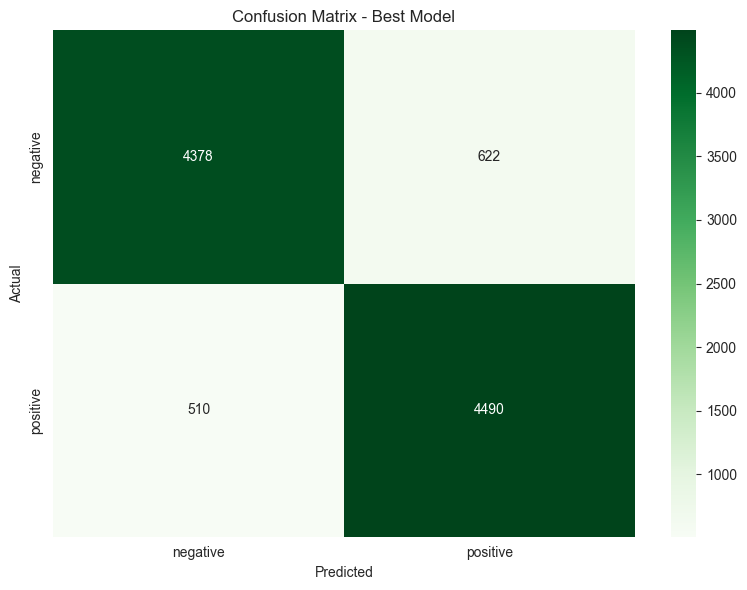

In [73]:

# =============================================================================
# 5. Evaluate Best Model on Test Set
# =============================================================================
best_model = grid_search.best_estimator_

y_pred_train_best = best_model.predict(X_train)
y_pred_test_best = best_model.predict(X_test)

test_f1_best = f1_score(y_test, y_pred_test_best)
test_acc_best = accuracy_score(y_test, y_pred_test_best)

print("\nBest Model Performance:")
print(f"Test F1 Score: {test_f1_best:.4f}")
print(f"Test Accuracy: {test_acc_best:.4f}")

print("\nClassification Report (Test Set - Best Model):")
print(classification_report(y_test, y_pred_test_best, target_names=['negative', 'positive']))

# Confusion matrix - best model
cm_best = confusion_matrix(y_test, y_pred_test_best)
plt.figure(figsize=(8,6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Greens',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Best Model')
plt.tight_layout()
plt.savefig('../reports/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()



In [74]:
# =============================================================================
# 6. Save Model and Metrics
# =============================================================================
os.makedirs('../models', exist_ok=True)

model_path = '../models/sentiment_pipeline.joblib'
joblib.dump(best_model, model_path)
print(f"Model saved to {model_path}")

metrics = {
    'best_params': grid_search.best_params_,
    'cv_f1_mean': grid_search.best_score_,
    'test_f1': test_f1_best,
    'test_accuracy': test_acc_best,
    'train_f1': f1_score(y_train, y_pred_train_best),
    'train_accuracy': accuracy_score(y_train, y_pred_train_best)
}

metrics_path = '../models/metrics.json'
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"Metrics saved to {metrics_path}")




Model saved to ../models/sentiment_pipeline.joblib
Metrics saved to ../models/metrics.json



Top 20 positive features (associated with positive sentiment):
        feature  coefficient
1989      excel     7.473602
2677      great     6.286131
4634    perfect     5.910197
2882     hilari     4.977944
1884      enjoy     4.942978
546        best     4.921534
202        amaz     4.914792
2115    favorit     4.728510
733   brilliant     4.506512
6086     superb     4.205124
6352      today     4.195427
2483        fun     4.118066
502      beauti     4.112672
3670       love     4.020777
1448    definit     3.968700
2086    fantast     3.927655
6549      uniqu     3.721530
2498   funniest     3.657284
6388      touch     3.583363
6111    surpris     3.540532

Top 20 negative features (associated with negative sentiment):
         feature  coefficient
3152     instead    -4.498508
6749   wast time    -4.507858
5256     ridicul    -4.596516
244        annoy    -4.671095
3417        lack    -4.774608
6100      suppos    -5.038823
4784      poorli    -5.146995
2946     horribl    -5.

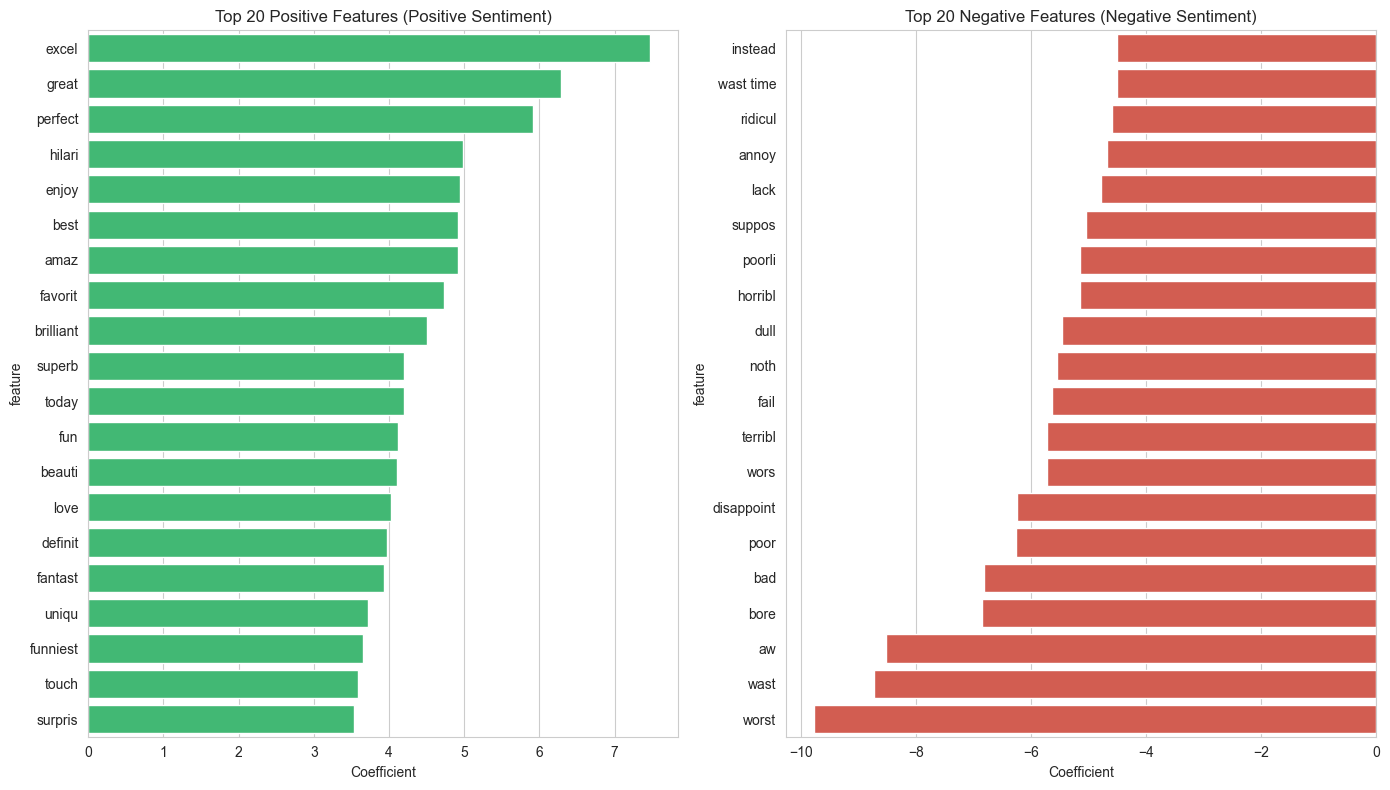

In [75]:
# =============================================================================
# 7. Feature Importance Analysis
# =============================================================================
feature_names = best_model.named_steps['tfidf'].get_feature_names_out()
coefs = best_model.named_steps['clf'].coef_.flatten()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefs
}).sort_values('coefficient', ascending=False)

print("\nTop 20 positive features (associated with positive sentiment):")
print(feature_importance.head(20))

print("\nTop 20 negative features (associated with negative sentiment):")
print(feature_importance.tail(20))

# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 8))

# Top positive features
top_pos = feature_importance.head(20)
sns.barplot(data=top_pos, x='coefficient', y='feature', ax=axes[0], color='#2ecc71')
axes[0].set_title('Top 20 Positive Features (Positive Sentiment)')
axes[0].set_xlabel('Coefficient')

# Top negative features (most negative coefficients)
top_neg = feature_importance.tail(20)
sns.barplot(data=top_neg, x='coefficient', y='feature', ax=axes[1], color='#e74c3c')
axes[1].set_title('Top 20 Negative Features (Negative Sentiment)')
axes[1].set_xlabel('Coefficient')

plt.tight_layout()
plt.savefig('../reports/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()


In [76]:
# =============================================================================
# 8. Example Predictions (optional)
# =============================================================================
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import re

def clean_new_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    stop_words = set(stopwords.words('english'))
    words = [w for w in words if w not in stop_words]
    stemmer = PorterStemmer()
    words = [stemmer.stem(w) for w in words]
    return ' '.join(words)

def predict_sentiment(text, model):
    cleaned = clean_new_text(text)
    pred = model.predict([cleaned])[0]
    proba = model.predict_proba([cleaned])[0]
    sentiment = "Positive" if pred == 1 else "Negative"
    confidence = proba[pred]
    return sentiment, confidence, cleaned

examples = [
    "This movie was absolutely fantastic! I loved every minute of it.",
    "Worst film ever made. Complete waste of time.",
    "It was okay, not great but not terrible either."
]

for ex in examples:
    sentiment, conf, cleaned = predict_sentiment(ex, best_model)
    print(f"Text: {ex}")
    print(f"Cleaned: {cleaned}")
    print(f"Predicted Sentiment: {sentiment} (confidence: {conf:.4f})\n")

print("Model training complete!")
print(f"Best F1 Score on Test Set: {test_f1_best:.4f}")
print(f"Best Accuracy on Test Set: {test_acc_best:.4f}")
print("Model and metrics saved in ../models/")
print("Plots saved in ../reports/")
print("Next step: Use the model for inference with predict.py script.")

Text: This movie was absolutely fantastic! I loved every minute of it.
Cleaned: movi absolut fantast love everi minut
Predicted Sentiment: Positive (confidence: 0.7301)

Text: Worst film ever made. Complete waste of time.
Cleaned: worst film ever made complet wast time
Predicted Sentiment: Negative (confidence: 0.9998)

Text: It was okay, not great but not terrible either.
Cleaned: okay great terribl either
Predicted Sentiment: Negative (confidence: 0.9241)

Model training complete!
Best F1 Score on Test Set: 0.8881
Best Accuracy on Test Set: 0.8868
Model and metrics saved in ../models/
Plots saved in ../reports/
Next step: Use the model for inference with predict.py script.
